<a href="https://colab.research.google.com/github/ohta-ee-ous/Lecture_ImageProcessing/blob/main/%E7%94%BB%E5%83%8F%E5%87%A6%E7%90%86%E6%BC%94%E7%BF%92_1_%E7%94%BB%E5%83%8F%E3%81%AE%E3%83%87%E3%83%BC%E3%82%BF%E8%A1%A8%E7%8F%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
<!--岡山理科大学 工学部 電気電子システム学科-->
<!--制作：太田寛志-ohta@ous.ac.jp-->

デジタル画像処理演習

<h1>画像のデータ表現</h1>

2026/04/20 改訂

---

この演習では、画像のデータ表現に関して以下の内容を学習します。

1. 画像の入力と出力
1. カラー画像とグレイスケール画像
1. デジタル画像のデータ構造
1. 色の表現
1. カラーチャンネル
1. 画像のヒストグラム

次に書かれている「準備」から順番に進めていってください。  

<a name="junbi"></a>
# **準備**

最初に準備を行います。次のコードを実行してください。

In [ ]:
#@title ⌨ 準備
# 外部モジュールを取り込む
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
from google.colab.patches import cv2_imshow
from ipywidgets import interact, interactive, IntSlider, FloatSlider
from IPython.display import display

# ユーザーのディスプレイの解像度に合わせて画像の画面表示サイズを調整する
screen_resolution = output.eval_js('[window.screen.width, window.screen.height, screen.orientation.type]')
screen_scale = max(screen_resolution[:2])/1920
def show_image(img):
  if screen_scale >= 1.0:
    cv2_imshow(img)
  else:
    cv2_imshow(cv2.resize(img, None, fx=screen_scale, fy=screen_scale))

# 使用するデータをダウンロードする。
!wget -nc "https://github.com/ohta-ee-ous/Lecture_ImageProcessing/releases/download/v1.0.0/imagefiles.zip" -O imagefiles.zip
!unzip -nq imagefiles.zip
!rm -f imagefiles.zip
!if [[ -f "asagao.png" && -f "README.txt" ]]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi

「準備が完了しました。」と表示されれば成功です。
次のライブラリや関数が使えるようになっています。

|名称|説明|
|:---|:---|
|cv2|画像処理ライブラリ OpenCV|
|np|数値計算ライブラリ NumPy|
|plt|グラフ描画ライブラリ Matplotlib|
|cv2_imshow|Colab専用の画像表示関数|

画像ファイルも用意されています。Colab の画面の左端にある「ファイル」アイコン（📁の形）をクリックするとファイルブラウザが表示されて、ファイルの一覧を見ることができます。もう一度クリックすると非表示になります。  
自分のパソコンに保存してある画像ファイルを Colab で使いたい場合には、このファイルブラウザの中へ画像ファイルをドラッグ＆ドロップしてください。

<br>

# **1．画像の入力と出力**

##画像ファイルからの読み込み

画像処理を行うためには、まず、コンピュータに画像データを読み込んで、コンピュータのメモリーの中に記憶する必要があります。

コンピュータプログラムでは次のような手順になります。

1. **関数**を使って、画像ファイルからデータ読み込む。
1. 代入式を使って、読み込んだデータを**変数**に記憶する。

次のコードで画像データが読み込めます。実行してみましょう。

In [ ]:
#@title ⌨ 画像ファイルの読み込み
src = cv2.imread('cleome.jpg')

変数に記憶されるだけですので、実行しても表示はされません。

`cv2.imread()`は、画像ファイルの読み込みを行う関数です。`cv2.imread('cleome.jpg')`と書くことによって、画像ファイル「`cleome.jpg`」からのデータを読み込みます。
読み込んだデータは、代入式 ` = ` によって、`src`という名前の変数に記憶しています。

<div><h3>画像データの読み込み方法のまとめ</h3></div>

- 画像ファイルを読み込むには、`cv2.imread`関数を使います。これは、画像処理ライブラリ OpenCV の中で定義されている関数です。
- `cv2.imread`関数の引数に読み込む画像ファイルの名前を与えます。ファイル名はシングルクォート`'`、または、ダブルクォート`"`で囲む必要があります。
- 読み込んだ画像データは、代入式を使って変数に記憶します。

##画像の表示

次に画像の表示について見ていきましょう。次のコードで画像の表示ができます。  
実行して確認してください。

In [ ]:
#@title ⌨ 画像の表示
show_image(src)

`show_image()`は、この演習で用意している独自の関数です。上の準備のところで関数定義していました。`show_image(src)`と書くことによって、変数`src`に記憶されているデータを画像として表示します。

<div><h3>画像の表示方法のまとめ</h3></div>

- この演習では、画像の表示に`show_image`関数を使います。これは本演習専用の関数です。
- `show_image`関数の引数に画像データが記憶されている変数の名前を与えます。
- 実行すると、コードのすぐ下に画像が表示されます。
- OpenCVには画像を表示する`cv2.imshow`関数があります。通常はこちらを使うのですが、Colabでは使用できません。

<details><summary><i>cv2.imshow関数について</i>（←クリックすると開きます）</summary>

---
OpenCVで画像を表示する場合には、本来は`cv2.imshow`関数を使用して、画像を新たなウインドウに表示させます。しかし、Colab は Webブラウザ上で動作する特殊な環境のため`cv2.imshow`関数は使用できません。代わりに、`cv2_imshow`関数が用意されています。本演習ではこの`cv2_imshow`関数に、ディスプレイの解像度に合わせて画像サイズを変更する機能を加えた`show_image`関数を使用します。

---
</details>

##画像ファイルへの保存

変数に記憶されている画像は、ファイルに保存することができます。

変数`src`の画像を「`画像.jpg`」というファイル名で保存してみましょう。  
次のコードを実行してください。

In [ ]:
#@title ⌨ 画像のファイル保存
cv2.imwrite('画像.jpg', src)

実行するとコードの下に`True`と表示されますが気にしなくていいです。 Colab のファイルブラウザで、`画像.jpg`というファイルができていることを確かめてください（リストの一番下にあるはずです）。作成したファイルがファイルブラウザに表示されるまで少し時間がかかる場合があります。

`cv2.imwrite()`は、画像ファイルに画像データの保存を行う関数です。`cv2.imwrite('画像.jpg', src)`と書くことによって、「`画像.jpg`」というファイルを新しく作り、その中に変数`src`に記憶されているデータを書き込みます。

<div><h3>画像データの保存方法のまとめ</h3></div>

- 画像をファイル保存するには、`cv2.imwrite`関数を使います。
- `cv2.imwrite`関数の一つ目の引数に画像ファイルの名前を文字列として与え、二つ目の引数に画像が格納されている変数の名前を与えます。  
- `cv2.imwrite`関数は、同名のファイルがすでに存在している場合はデータの上書きをします。そのため、必要なデータを誤って消してしまわないように、ファイルの名前には気を付けておく必要があります。


`cv2.imread`関数と`cv2.imwrite`関数で読み書きできる画像フォーマットには以下のものがあります（他にもあります）。画像フォーマットの種類はファイル拡張子（ファイル名の末尾につけられる文字）でもって区別されます。

|画像フォーマットの種類|フィル拡張子|
|:---|:---|
|JPEG|.jpg　.jpeg　.JPG|
|PNG |.png　.PNG|
|TIFF| .tiff　.TIFF|
|Windows Bitmap| .bmp　.BMP |

プログラムによって作成したファイルは、Colab の接続が切れると消えて無くなります。ファイルを残しておきたい場合は、接続を切る前に自分のパソコンへダウンロードしてください。ダウンロードするには、ファイルブラウザの中のファイル名の上で右クリックしてポップアップメニューを表示して「ダウンロード」を選択します。


### ✍ 実践問題 1

実践問題を解いて画像処理を身につけていきましょう。

この下に書かれている「実践問題用コード 1」を次の指示に従って書き変えてください。
書き変えたら、コードを実行して、指示通りになっているか確かめましょう。

1. コードの2行目に書かれているファイルの名前を`sazanka.jpg`に替えて、画像を表示してみよう。
1. 変数の名前は自由につけられます。変数の名前を`image`に替えて実行してみよう。
1. 最後の行にコードを追加して、`山茶花.png`というファイル名で保存してみよう。

<details><summary>答え（←クリックすると開きます）</summary>

```
image = cv2.imread('sazanka.jpg')
cv2_imshow(image)
cv2.imwrite('山茶花.png', image)
```

In [ ]:
#@title ⌨ 実践問題用コード 1
src = cv2.imread('cleome.jpg')
show_image(src)

<br>

# **2．カラー画像とグレイスケール画像**

画像は色の表現の仕方によって、**カラー画像**と**グレイスケール画像**の2種類に分けられます。

カラー画像は名前の通り、色がついている画像です。テレビやパソコン画面、カメラ撮影などではカラー画像が使われていますね。一方、グレイスケール画像は色がなく、明暗があるだけの画像で、黒色と白色とその中間の明るさの灰色からなります。コピー機でモノクロコピーをとるとグレイスケール画像になりますね。ほかに、文書画像、設計図などの図面、バーコード・QRコード、レントゲン写真などもグレイスケール画像です。

次のコードを実行して、カラー画像とグレイスケール画像を見てみましょう。

In [ ]:
#@title ⌨ カラー画像とグレイスケール画像
color = cv2.imread('sunflower.jpg')
gray  = cv2.imread('sunflower.jpg', cv2.IMREAD_GRAYSCALE) # グレイスケール画像として読み込む
print('カラー画像')
show_image(color)
print('\nグレイスケール画像')
show_image(gray)

上がカラー画像で、下がグレイスケール画像です。カラー画像は鮮やかですね。  
`cv2.imread`関数の2番目の引数に`cv2.IMREAD_GRAYSCALE`と書くと、読み込んだ画像がグレイスケール画像に変換されます。このコードでは、`color`と`gray`の二つの変数に同じひまわりの画像ファイルから読み込みを行っていますが、`gray`の方はグレイスケール画像に変換してから記憶しています。

画像のデータ表現としては、グレイスケール画像の方が色の情報がない分だけシンプルな構造になります。

<br>

# **3．デジタル画像のデータ構造**

次に、画像の構造やデータ表現について見ていきましょう。

##画像の画素と座標系

デジタル画像は明るさをもつ点が格子状に（碁盤の目のように）並んで作られています。この点のことを**画素**（または**ピクセル**）と呼びます。画素がたくさん集まって、写真やイラストなどの画像ができあがります。

画像の例として、横幅と縦幅がともに$8$画素のグレイスケール画像を下の図に示します。
画素は実際には一つの点ですが、この図では分かりやすいように一つの正方形に拡大して表しています。
画素の位置は2次元の座標を使って表します。一般的に、**左上端の画素の座標が原点$(0,0)$**になります。そのため、**$x$軸（横軸）は右向き**、**$y$軸（縦軸）は下向き**になります。座標は整数値（$0,1,2,3,\cdots$）だけをとります。

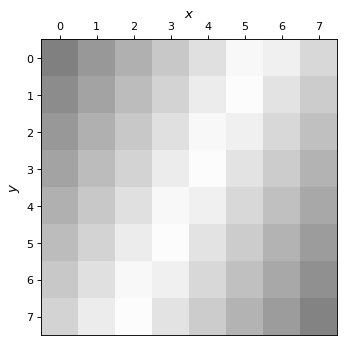

In [ ]:
#@title 🖼️ 画像の構造
sample = np.array([[256-abs((i+j*2)*12-128) for j in range(8)] for i in range(8)], 'uint8') # 画像データをつくる
# Matplotlibで表示
fig, ax = plt.subplots(dpi=80)              # 描画領域を準備
ax.imshow(sample, 'gray', vmin=0, vmax=255) # 画像を貼り付け
ax.set_xlabel('$x$', fontsize=12)           # x軸にラベルを表示
ax.set_ylabel('$y$', fontsize=12)           # y軸にラベルを表示
ax.xaxis.tick_top()                         # x軸を上に表示
ax.xaxis.set_label_position('top')          # x軸のラベルを上に表示

画像サイズが、横幅が $M$ 画素、縦幅が $N$ 画素の場合、画像の座標 $(x,y)$ の値の範囲は、
$$0\leqq x\leqq M-1$$
$$0\leqq y\leqq N-1$$
になります。座標の最大値は、幅の画素数よりも$1$画素小さな値になることに注意してください。

##画素値

画素の明るさは整数値で表します。この数値のことを**画素値**といいます。明るさは一般的に $0$ から $255$ までの $256$ 段階で表現されます。この明るさの段階の数を**階調数**と呼びます。
画素値（Pixel value）と明るさの関係を下の図に示します。画素値 $0$ が最も暗く、画素値 $255$ が最も明るくなります。

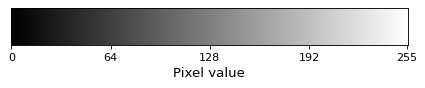

In [ ]:
#@title 🖼️ 画素値と明るさ
sample = [np.arange(256)]*24                # グラデーションの画像をつくる
fig, ax = plt.subplots(dpi=80)              # 描画領域を用意
ax.imshow(sample, 'gray', vmin=0, vmax=255) # 画像の貼り付け
ax.tick_params(labelleft=False, left=False) # y軸の目盛りとラベルを非表示
ax.set_xticks([0, 64, 128, 192, 255])       # x軸の目盛りの設定
ax.set_xlabel('Pixel value', fontsize=12);  # x軸のラベルを表示

「座標 $(x,y)$ の画素の画素値」を数学的に表現する場合は、
$$f(x,y)$$
のように関数のような形で書き表します。$f$は画像につける名前だと思ってください。  
これを使って、「画素値がとりうる値の範囲は $0$ から $255$ まで」ということを数学的に表現すると、
$$0\leqq f(x,y)\leqq 255$$
となります。

## 画像データの記述

それでは、1枚の画像は具体的にどのように記述するのか見てみましょう。

一つの例を次に示します。これは、横幅が$5$画素、縦幅も$5$画素のグレイスケール画像のデータです。

$$\begin{pmatrix}
50 & 75 & 100 & 125 & 150\\
75 & 100 & 125 & 150 & 175\\
100 & 125 & 150 & 175 & 200\\
125 & 150 & 175 & 200 & 225\\
150 & 175 & 200 & 225 & 250
\end{pmatrix}$$

このように数値が縦横にならんだデータ構造のことをコンピュータの世界では**2次元配列**と言います。**配列**とは、複数のデータを並べてひとまとめにして取り扱うデータ構造です。一列だけで並んでいれば1次元配列、上のように縦と横に並んでいれば2次元配列になります。1次元配列は数学の世界における**ベクトル**、2次元配列は**行列**と見なすことができます。

上の画像データを見てみると、左上は値が小さく、右下の方に向かって値が大きくなっていることが分かりますね。このことから、この画像は右下へ向けて徐々に明るくなっていると想像できます。

この画像データをコードで書き表すと次のようになります。
画像を記憶する変数名は`img`としています。
画素値は`,`で区切り、全体を`()`で囲みます。

データの記述の仕方はいろいろありますが、ここではコードが見やすいことを優先して、1次元配列の形で`img`に格納した後、`img`を2次元配列に成形するという方法をとっています。ちょっと難しいので理解できなくても構わないです。上の画像データと同じ数値がコード内に書かれているということを確かめてください。

In [ ]:
#@title ⌨ グレイスケール画像のデータをつくる
img = (  50,  75, 100, 125, 150,
         75, 100, 125, 150, 175,
        100, 125, 150, 175, 200,
        125, 150, 175, 200, 225,
        150, 175, 200, 225, 250 )

# 5行5列の2次元配列に成形
img = np.array(img).reshape(5, 5)

実際に画像にして表示してみましょう。今回は、グラフ描画ライブラリの Matplotlib を使って画像を表示します。  
**上のコードを実行してから**、次のコードを実行してください。

In [ ]:
#@title ⌨ Matplotlibで画像を表示
def show_image_plt(img):
  fig, ax = plt.subplots(dpi=80)           # 描画領域を設定
  ax.imshow(img, 'gray', vmin=0, vmax=255) # グレイスケール画像を表示
  ax.set_xlabel('$x$', fontsize=12)        # x軸にラベルをつける
  ax.set_ylabel('$y$', fontsize=12)        # y軸にラベルをつける
  ax.xaxis.tick_top()                      # x軸の目盛りの位置を上にする
  ax.xaxis.set_label_position('top')       # x軸のラベルの位置を上にする
show_image_plt(img)

上の画像データから想像した通り、画像の右下へ向けて徐々に明るくなっていますね。

### ✍ 実践問題 2

画像データを書き換えて、画像を表示してみましょう。
次の「実践問題用コード 2」の3行目～7行目に画素値が記されています。数値の並びの順序は上の変数`img`と同じです。画素値を次の指示通りに書き換えて、コードを実行してください。

1. 座標$(3,1)$の画素を黒色（明るさ最小）にしよう。
1. 座標$(2,3)$の画素を白色（明るさ最大）にしよう。
1. $y=4$の位置の画素値を左から `198, 199, 200, 201, 202` にして、画素値の差が1の明るさが見分けつくか試してみよう。見分けがつかない場合は数値の差を大きくしてみよう。

<details><summary>答え</summary>

```
img = (  50,  75, 100, 125, 150,
         75, 100, 125,   0, 175,
        100, 125, 150, 175, 200,
        125, 150, 255, 200, 225,
        198, 199, 200, 201, 202 )
```
</details>

In [ ]:
#@title ⌨ 実践問題用コード 2
# 画像データを書き変えましょう
# ↓――――ここから――――↓
img = (  50,  75, 100, 125, 150,
         75, 100, 125, 150, 175,
        100, 125, 150, 175, 200,
        125, 150, 175, 200, 225,
        150, 175, 200, 225, 250 )
# ↑――――ここまで――――↑

# 5行5列の2次元配列に成形
img = np.array(img).reshape(5, 5)
# Matplotlibで画像表示
show_image_plt(img)

<br>

# **4．色の表現**

各画素の明るさを画素値で表すことを見てきましたが、明るさの情報だけではグレイスケール画像にしかならず、カラー画像がつくれません。
それでは次に、色の表現の仕方を見ていきましょう。

##光の3原色と加法混色

カラー画像において色を表現するには、**光の3原色**を利用します。
光の3原色とは、🟥赤色（Red）、🟩緑色（Green）、🟦青色（Blue）のことで、略して **RGB** とも呼びます。
この3色を組み合わせることで、下の図のように他を色をつくることができます。これを**加法混色**と言います。

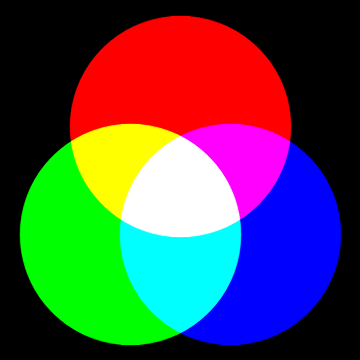

In [ ]:
#@title 🖼️ 光の3原色と加法混色
red   = np.zeros((360, 360, 3), 'uint8') # 黒色の画像をつくってredに格納
green = np.zeros((360, 360, 3), 'uint8') # 黒色の画像をつくってgreenに格納
blue  = np.zeros((360, 360, 3), 'uint8') # 黒色の画像をつくってblueに格納
cv2.circle(red, (180, 126), 110, (0, 0, 255), -1, cv2.LINE_AA)   # redに赤色の●を描く
cv2.circle(green, (130, 234), 110, (0, 255, 0), -1, cv2.LINE_AA) # greenに緑色の●を描く
cv2.circle(blue, (230, 234), 110, (255, 0, 0), -1, cv2.LINE_AA)  # blueに青色の●を描く
cv2_imshow(red + green + blue) # red,green,blueの画像を合成して表示

3原色の🟥赤色、🟩緑色、🟦青色の明るさは、グレイスケール画像と同じく、それぞれ $0$ から$255$ までの $256$段階の画素値で表します。したがって、色の組み合わせの数は、$256\times 256\times 256$となるので、カラー画像で表現できる色数は 16,777,216色となります。

### ✍ 実践問題 3

光の3原色を組み合わせてさまざまな色をつくってみましょう。  
次の実践問題用コード3を実行すると、赤、緑、青の画素値を調整するスライダーが表示されます（コードの書き変えは行いません）。

スライダーを動かして、加法混色によって次の色をつくってみましょう。
1. <font color="#717375">■</font>灰色をつくってみよう。
1. <font color="#8b52a1">■</font>紫色をつくってみよう。
1. <font color="#f09199">■</font>桃色をつくってみよう。

<details><summary>答え</summary>

カラーコードにおいては以下のように値が定義されています。
- 灰色 = (赤 113, 緑 115, 青 117)  
- 紫色 = (赤 139, 緑 82, 青 161)  
- 桃色 = (赤 240, 緑 145, 青 153)

赤、緑、青の画素値をほぼ同じにすると灰色の系統になります。紫色や桃色は、緑の画素値を小さめ、赤と青の画素値を大きめにします。赤よりも青の方をやや大きめにすると紫色に近くなり、逆に青よりも赤の方をやや大きめにすると桃色に近くなります。
</details>


In [ ]:
#@title ⌨ 実践問題用コード 3
# このコードは書き換えないでください
from ipywidgets import interactive, IntSlider
from IPython.display import display

imgR = np.zeros((360, 360, 3), 'uint8')
imgG = np.zeros((360, 360, 3), 'uint8')
imgB = np.zeros((360, 360, 3), 'uint8')

# R,G,Bのそれぞれの円を作って加法混色して表示
def synthesis(r, g, b):
  cv2.circle(imgR, (180, 126), 110, (0, 0, r), -1, cv2.LINE_8)
  cv2.circle(imgG, (130, 234), 110, (0, g, 0), -1, cv2.LINE_8)
  cv2.circle(imgB, (230, 234), 110, (b, 0, 0), -1, cv2.LINE_8)
  cv2_imshow(imgR + imgG + imgB)

# スライダーでR,G,Bの画素値を入力
r = IntSlider(min=0, max=255, step=1, value=255, description='赤の画素値')
g = IntSlider(min=0, max=255, step=1, value=255, description='緑の画素値')
b = IntSlider(min=0, max=255, step=1, value=255, description='青の画素値')
ui = interactive(synthesis, r=r, g=g, b=b)
display(ui)

## カラー画像のデータ表現

カラー画像では、1画素につき、🟥赤色、🟩緑色、🟦青色の3つの画素値をもちます。これを$($赤$, $ 緑$,$ 青$)$の並びで表記すると、
カラー画像のデータは次のように表されます。

$$\begin{pmatrix}
( 50, 0, 0) & (0, 0, 250) & ( 50, 0,  50) & (  0, 255, 255) & (255,   0, 0)\\
(100, 0, 0) & (0, 0, 200) & (100, 0, 100) & ( 64, 255, 192) & (192,  64, 0)\\
(150, 0, 0) & (0, 0, 150) & (150, 0, 150) & (128, 255, 128) & (128, 128, 0)\\
(200, 0, 0) & (0, 0, 100) & (200, 0, 200) & (192, 255,  64) & ( 64, 192, 0)\\
(250, 0, 0) & (0, 0,  50) & (250, 0, 250) & (255, 255,   0) & (  0, 255, 0)
\end{pmatrix}$$

グレイスケール画像と比べて、情報がだいぶ多くなりましたね。  
一番左の縦の列は、$(50,0,0)$から$(250,0,0)$に徐々に値が変わっています。この$50\sim 250$は赤色の画素値を表しています。緑と青の画素値はずっと$0$のままですので、画像としては、暗い赤色から明るい赤色に変わっていくと予想できます。
一番右の列は、$(255,0,0)$から$(0,255,0)$に変わっていっています。$(255,0,0)$は赤色で、$(0,255,0)$は緑色です。ですので、この列は、赤色から緑色へ変わっていくグラデーションになっていると予測できます。ほかの列についても、どのようになるのか予想してみましょう。

上のデータをコードで書き表すと、次のようになります。

In [ ]:
#@title ⌨ カラー画像のデータをつくる
img = ( ( 50, 0, 0), (0, 0, 250), ( 50, 0,  50), (  0, 255, 255), (255,   0, 0),
        (100, 0, 0), (0, 0, 200), (100, 0, 100), ( 64, 255, 192), (192,  64, 0),
        (150, 0, 0), (0, 0, 150), (150, 0, 150), (128, 255, 128), (128, 128, 0),
        (200, 0, 0), (0, 0, 100), (200, 0, 200), (192, 255,  64), ( 64, 192, 0),
        (250, 0, 0), (0, 0,  50), (250, 0, 255), (255, 255,   0), (  0, 255, 0) )

# 5行5列3チャンネルに成形
img = np.array(img).reshape(5, 5, 3)

実際に画像にして表示してみましょう。**上のコードを実行してから**、次のコードを実行してください。

In [ ]:
#@title ⌨ Matplotlibで画像を表示
show_image_plt(img)

予想通りの結果になりましたか？

<br>

# **5．カラーチャンネル**

##チャンネルの分割

カラー画像は、赤色の明るさの情報をもつ画像と、緑色の明るさの情報をもつ画像と、青色の明るさの情報をもつ画像の3つを合成したものと考えることができます。
この色ごとに分けた画像のことを**チャンネル**と言います。
つまり、カラー画像は、赤チャンネル、緑チャンネル、青チャンネルの3つに分割することができます。
それぞれのチャンネルは、明るさの情報だけになっているので、グレースケール画像と同じになります。

実際にカラー画像をチャンネルに分割してみましょう。次のコードでは、赤チャンネルは変数`red`に、緑チャンネルは変数`green`に、青チャンネルは変数`blue`に記憶します。
そして、それぞれのチャンネルを表示します。コードを実行してみてください。

In [ ]:
#@title ⌨ カラー画像のチャンネル分割
src = cv2.imread('eggs.jpg')
# カラー画像の青、緑、赤チャンネルを分割
blue, green, red = cv2.split(src)
print('原画像')
show_image(src)
print('\n左から、🟥赤チャンネル、🟩緑チャンネル、🟦青チャンネル')
show_image(cv2.hconcat([red, green, blue])) # 横につなげて表示する

グレイスケール画像が3つ表示されましたね。左から、🟥赤チャンネル、🟩緑チャンネル、🟦青チャンネルの画像です。原画像にある赤色のたまごに注目してみると、赤チャンネルでは明るい白色になっていて、緑チャンネルと青チャンネルでは黒くなっています。また、黄色のたまごは、赤チャンネルと緑チャンネルでは明るい白色、青チャンネルでは黒くなっています。

カラー画像をチャンネルに分解するには、`cv2.split`関数を使います。引数にカラー画像を与えると、3つのチャンネルの画像が返されます。このとき、返ってくるチャンネルの順番は、🟦青、🟩緑、🟥赤の順になっています。🟥赤、🟩緑、🟦青の順番ではないので注意してください。

##チャンネルの合成

今度は、上のコードで作った赤、緑、青のチャンネルの画像を合成してカラー画像を作ってみましょう。
次のコードを実行してください。

In [ ]:
#@title ⌨ チャンネルを合成してカラー画像をつくる
dst = cv2.merge([blue, green, red])
show_image(dst)

もとのカラー画像になりましたね。チャンネルを合成するには`cv2.merge`関数を使います。  
与えるチャンネルの順番は、🟦青、🟩緑、🟥赤の順になります。

では、赤と緑のチャンネルだけを使って画像を合成したらどのような画像になるでしょうか。  
次のコードを実行してください。

このコードでは、全画素の画素値を 0 にした画像をつくり、`none`という変数に格納しています。合成するとき、青チャンネルにこの`none`を与えて、青チャンネルの情報だけを消しています。  

In [ ]:
#@title ⌨ 赤と緑のチャンネルだけで画像をつくる
src = cv2.imread('eggs.jpg')
blue, green, red = cv2.split(src)       # カラー画像を赤、緑、青のチャンネルに分割
none = np.zeros(src.shape[:2], 'uint8') # 原画像と同じサイズで無地（黒）画像をつくる

# カラーチャンネルの合成
# 赤チャンネルにred、緑チャンネルにgreen、青チャンネルにnoneを割り当てる
dst = cv2.merge([none, green, red])
show_image(dst)

原画像と見比べてみると、赤色や黄色、緑色のたまごは、ほぼそのままの色ですが、水色のたまごが緑色に変わっていますね。紫色のたまごも茶色に変わっています。  
この結果から、青チャンネルの情報がなくなったことによって、水色や紫色の再現ができなくなったことが分かります。

### ✍ 実践問題 4

`cv2.merge`関数に与える変数を書き換えて、次のようにカラー画像を合成をしてみましょう。
1. 赤チャンネルだけを使って合成してみよう。
1. 緑チャンネルと青チャンネルだけを使って合成してみよう。
1. 赤チャンネルと青チャンネルを入れ替えて合成してみよう。緑チャンネルはそのまま。

<details><summary>答え</summary>

1. `dst = cv2.merge([none, none, red])`
1. `dst = cv2.merge([blue, green, none])`
1. `dst = cv2.merge([red, green, blue])`


In [ ]:
#@title ⌨ 実践問題用コード 4
dst = cv2.merge([blue, green, red]) # [ ]の中を書き換える。使わないチャンネルには none を指定する。
show_image(dst)

<br>

# **6．画像のヒストグラム**

画像データは、画素値という数値の集まりですので、統計的な解析を行うことができます。
まずは、画素値の分布をグラフにして見てみましょう。このようなグラフのことを**ヒストグラム**といいます。

##グレースケール画像のヒストグラム

グレイスケール画像における画素値の分布を求めるには、`cv2.clacHist`関数を使います。この関数の説明は長くなるので今回は省略します。

次のコードを実行して、ヒストグラムの例を見てみましょう。`cv2.imread`関数の2つ目の引数に`cv2.IMREAD_GRAYSCALE`を与えて、画像を読み込んだ後でグレイスケール画像に変換しています。

In [ ]:
#@title ⌨ グレイスケール画像のヒストグラム1
src = cv2.imread('fujisan.jpg', cv2.IMREAD_GRAYSCALE)
show_image(src)

# ヒストグラムを計算
hist = cv2.calcHist([src], [0], None, [256], [0, 256])
# グラフを描画
def show_histogram_gray(hist):
  fig, ax = plt.subplots(dpi=80,figsize=(6,4))   # 描画領域のサイズを設定
  ax.plot(hist, color='k', lw=2)                 # 黒色でグラフを描画
  ax.set_xlabel('Pixel value', fontsize=12)      # x軸に名前をつける
  ax.set_ylabel('Number of pixels', fontsize=12) # y軸に名前をつける
  ax.grid()                                      # グリッド線を描く
  fig.tight_layout()                             # 余白の自動調節
show_histogram_gray(hist)

富士山の画像ですね。画像の下にあるグラフがヒストグラムです。ヒストグラムの横軸は画素値（Pixel value）で、縦軸は画素数（Number of pixels）です。
グラフからは、画素値 170 あたりの中くらいの明るさの画素が多く存在していることが読み取れますね。また、画素値 50 以下の暗い画素や、画素値 240以上のとても明るい画素はなく、画素値の散らばり（分散）は小さいと言えそうです。

それでは、実際に統計量を計算してみましょう。統計量の計算に使える関数を下にまとめました。*data*には、画像データのような、数値の集合となっている変数を与えます。


|関数|働き|
|:---|:---|
|np.ave( *data* )| *data*の平均値 (average) を求める|
|np.var( *data* )| *data*の分散値 (variance) を求める|
|np.median( *data* )| *data*の中央値 (median) を求める|
|np.min( *data* )| *data*の最小値 (maximum) を求める|
|np.max( *data* )| *data*の最大値 (minimum) を求める|
|np.argmax( *data* )| *data*で最大値となる要素のインデックス (argument of the maximum) を求める
|

ここでは、画素値の平均値、分散値、最頻値の3つを求めてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ ヒストグラムの統計量
src  = cv2.imread('fujisan.jpg', cv2.IMREAD_GRAYSCALE)
hist = cv2.calcHist([src], [0], None, [256], [0, 256])
# 統計量の計算
print('画素値の平均値 =', np.mean(src)   )
print('画素値の分散値 =', np.var(src)    )
print('画素値の最頻値 =', np.argmax(hist)) # ヒストグラムが最大になる要素番号を求める

画素値の平均値、分散値、最頻値がそれぞれ表示されましたか？
最頻値の画素値が 170 ですので、グラフから読み取れた値と一致していますね。

`hist`は要素番号が $0\sim 255$ の配列変数であり、画素値 $0$から$255$までのそれぞれの画素数が格納されています。

### ✍ 実践問題 5

同じ画像で次の統計量も求めてみましょう。上の表を見て、どの関数を使えばよいか考えてください。
1. 画素値の中央値を表示してみよう。
1. 画素数の最大値を表示してみよう

<details><summary>答え</summary>

1. `print('画素値の中央値 =', np.median(src))`
1. `print('画素数の最大値 =', np.max(hist)  )`

中央値の計算には `np.median`関数を使います。画素値の中央値を求めるので、引数には画像データが入っている変数`src`を与えます。  
最大値の計算には `np.max`関数を使います。画素数の最大値を求めるので、引数には各画素値の画素数のデータが格納されている配列変数`hist`を与えます。

実行すると次のように表示が得られます。
```
画素値の中央値 = 170.0
画素数の最大値 = 8641.0
```

</details>

In [ ]:
#@title ⌨ 実践問題用コード 6

print('画素値の平均値 =', np.mean(src)   )
print('画素値の分散値 =', np.var(src)    )
print('画素値の最頻値 =', np.argmax(hist)) # ヒストグラムが最大になる要素番号を求める

print('画素値の中央値 =',                ) # 空欄に中央値を求める式を書く
print('画素数の最大値 =',                ) # 空欄に画素数の最大値を求める式を書く


別の画像を見てみましょう。

In [ ]:
#@title ⌨ グレイスケール画像のヒストグラム2
src = cv2.imread('okayamajo.jpg', cv2.IMREAD_GRAYSCALE)
show_image(src)
# ヒストグラムを計算
hist = cv2.calcHist([src], [0], None, [256], [0, 256])
show_histogram_gray(hist)

これは岡山城の画像です。ヒストグラムを見ると、画素値50付近の暗い色と、画素値210付近の明るい色の2極に分かれ、明暗の差の大きな画像だということが読み取れます。実際に画像を見ると、空の明るさと、お城の壁や瓦の明るさの差が際立っていますね。

このように、画像の性質をヒストグラムから読み解くことができます。

##カラー画像のヒストグラム

続いてカラー画像のヒストグラムを見てみましょう。
カラー画像では、赤、緑、青のチャンネルに分けて、それぞれヒストグラムを求めます。

次のコードを実行してください。

In [ ]:
#@title ⌨ カラー画像のヒストグラム1
src = cv2.imread('matterhorn.jpg')
show_image(src)
histR = cv2.calcHist([src], [2], None, [256], [0, 256])
histG = cv2.calcHist([src], [1], None, [256], [0, 256])
histB = cv2.calcHist([src], [0], None, [256], [0, 256])

def show_histogram_rgb(histR, histG, histB):
  fig, ax = plt.subplots(dpi=80,figsize=(6,4))   # 描画領域のサイズを設定
  ax.plot(histR, color='r', lw=2)
  ax.plot(histG, color='g', lw=2)
  ax.plot(histB, color='b', lw=2)
  ax.set_xlabel('Pixel value', fontsize=12)      # x軸に名前をつける
  ax.set_ylabel('Number of pixels', fontsize=12) # y軸に名前をつける
  ax.grid()                                      # グリッド線を描く
  fig.tight_layout()                             # 余白の自動調節
show_histogram_rgb(histR, histG, histB)

ヒストグラムの分布をみると、赤、緑、青ともに明るい色から暗い色まで、幅広く存在していることがわかります。このような画像をコントラストが高い画像と表現します。

別の画像を見てみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ カラー画像のヒストグラム2
src = cv2.imread('mejiro.jpg')
show_image(src)
histR = cv2.calcHist([src], [2], None, [256], [0, 256])
histG = cv2.calcHist([src], [1], None, [256], [0, 256])
histB = cv2.calcHist([src], [0], None, [256], [0, 256])
show_histogram_rgb(histR, histG, histB)

ヒストグラムでは、赤、緑、青どれも、狭い範囲の画素値が使われていますので、使われている色数は先ほどの画像よりも少ないと言えます。色数が少ないことによって、画像としては色のめりはりが利いていると言えるでしょう。

以上で、演習を終了します。

<br>

---
Copyright © 2026 OHTA Hiroshi @ Okayama University of Science  
<small>岡山理科大学 工学部 電気電子システム学科 太田研究室</small>

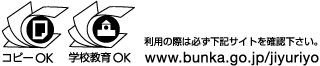  
この演習は、大学講義科目「画像工学」の講義資料として作成されています。  
このipynbファイルは、学校教育のための非営利目的利用を認めます。[https://www.bunka.go.jp/jiyuriyo](https://www.bunka.go.jp/jiyuriyo)  
この演習で使用している画像ファイル（imagefiles.zip、及び、imagefiles.zip 内の個々のファイル）については再配布を禁止します。